In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# 시드 고정
random.seed(42)
np.random.seed(42)

# 고객 수 및 주문 수
num_customers = 500
num_orders = 5000

# 고객 ID 목록
customer_ids = [f"C{str(i).zfill(4)}" for i in range(1, num_customers + 1)]

# 날짜 범위
start_date = datetime(2022, 1, 1)
end_date = datetime(2023, 12, 31)

# 카테고리, 디바이스, 채널, 할인 여부 목록
product_categories = ['Electronics', 'Fashion', 'Beauty', 'Grocery', 'Books', 'Sports']
devices = ['Mobile', 'Desktop', 'Tablet']
channels = ['Website', 'App', 'Offline']

# 주문 데이터 생성
orders = []
for _ in range(num_orders):
    cust_id = random.choice(customer_ids)
    order_date = start_date + timedelta(days=np.random.randint(0, (end_date - start_date).days))
    amount = round(np.random.exponential(scale=100), 2)
    category = random.choice(product_categories)
    device = random.choices(devices, weights=[0.6, 0.3, 0.1])[0]
    discount_used = random.choices([0, 1], weights=[0.7, 0.3])[0]
    channel = random.choices(channels, weights=[0.5, 0.4, 0.1])[0]

    orders.append([
        cust_id, order_date, amount, category, device, discount_used, channel
    ])

# 데이터프레임 구성
df_orders = pd.DataFrame(orders, columns=[
    "customer_id", "order_date", "amount", "category", "device", "discount_used", "channel"
])

# 날짜 타입 변환
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])

# 결과 확인
print(df_orders.head())

  customer_id order_date  amount     category   device  discount_used  channel
0       C0328 2022-04-13  159.23  Electronics   Mobile              0  Website
1       C0378 2022-09-28  131.67  Electronics  Desktop              1  Website
2       C0217 2023-12-02   90.84  Electronics   Mobile              0      App
3       C0014 2022-05-02   16.96        Books   Mobile              0      App
4       C0113 2022-11-27   61.48      Grocery   Mobile              1  Website


In [10]:
df_orders

,customer_id,order_date,amount,category,device,discount_used,channel
0,C0328,2022-04-13,159.23,Electronics,Mobile,0,Website
1,C0378,2022-09-28,131.67,Electronics,Desktop,1,Website
2,C0217,2023-12-02,90.84,Electronics,Mobile,0,App
3,C0014,2022-05-02,16.96,Books,Mobile,0,App
4,C0113,2022-11-27,61.48,Grocery,Mobile,1,Website
...,...,...,...,...,...,...,...
4995,C0313,2023-02-28,283.25,Grocery,Desktop,0,Website
4996,C0387,2023-01-17,20.56,Beauty,Mobile,0,App
4997,C0457,2023-11-05,516.52,Sports,Mobile,0,Website
4998,C0392,2022-10-04,15.00,Grocery,Mobile,1,App


### 고객 구매 패턴 확인 - 구매 패턴의 주기

In [12]:
import matplotlib.pyplot as plt

df_orders['year_month']=df_orders['order_date'].dt.to_period('M')
df_orders['year_week']=df_orders['order_date'].dt.strftime('%Y-%U')
df_orders['weekday']=df_orders['order_date'].dt.dayofweek # 0 monday
weekday_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# 전체 집계
total_monthly=df_orders.groupby('year_month').size().reset_index(name='total_orders')
total_weekly=df_orders.groupby('year_week').size().reset_index(name='total_orders')
weekday_counts=df_orders.groupby('weekday').size().reindex(range(7), fill_value = 0).reset_index(name='total_orders')
weekday_counts['weekday_label'] = weekday_labels

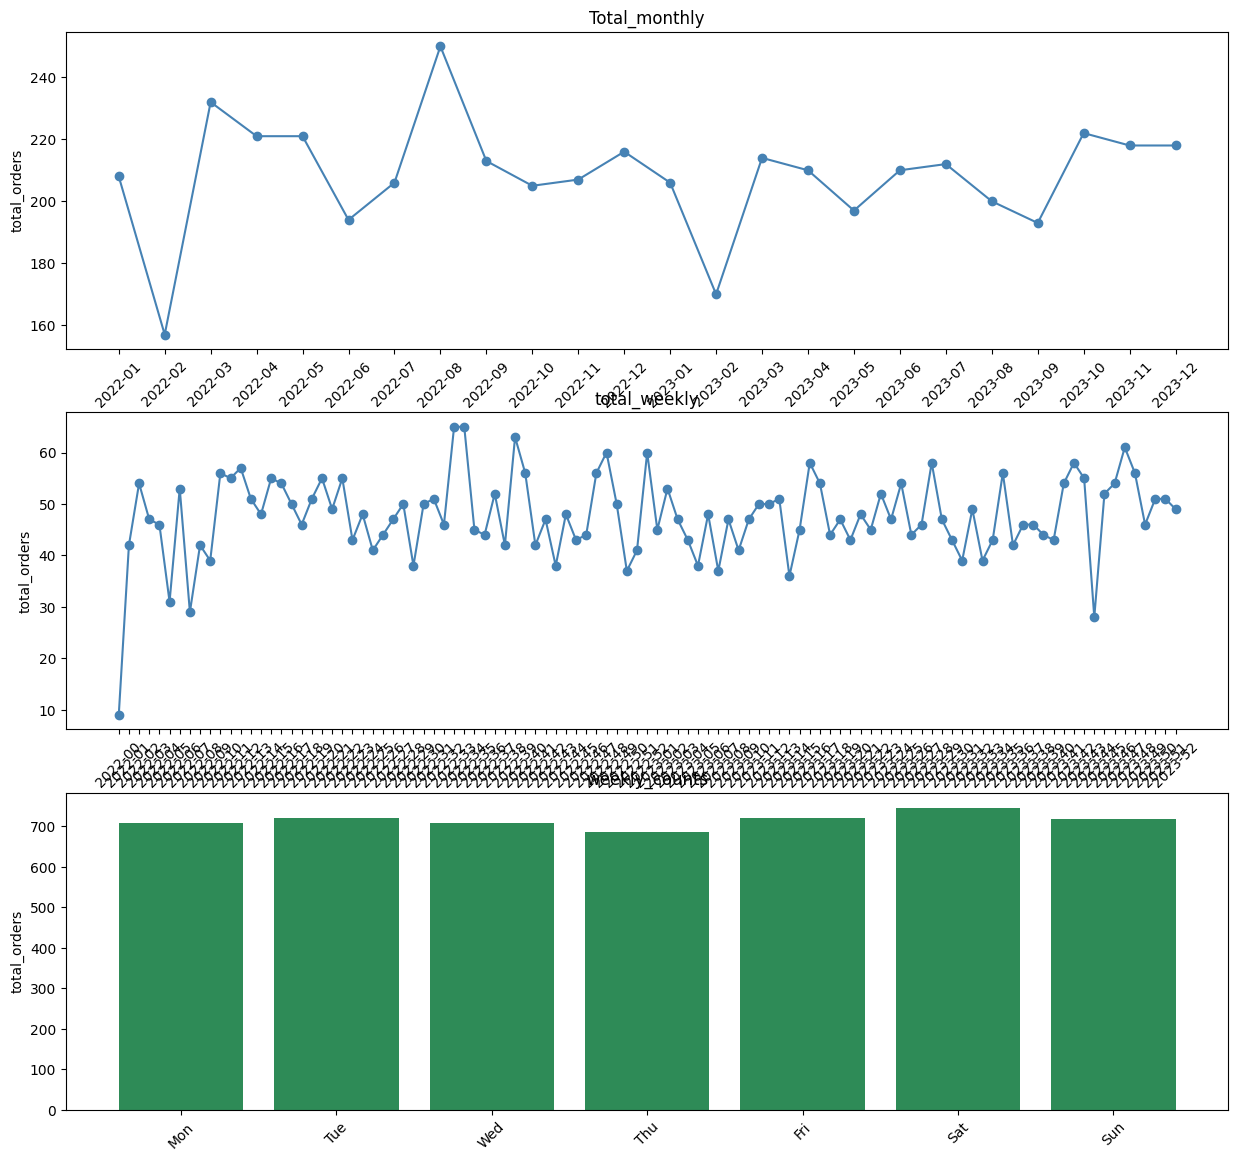

In [21]:
fig, axes = plt.subplots(3,1,figsize = (15, 14))

# 월별 트렌드
axes[0].plot(total_monthly['year_month'].astype(str), total_monthly['total_orders'], marker = 'o', color='steelblue')
axes[0].set_title('Total_monthly')
axes[0].set_ylabel('total_orders')
axes[0].tick_params(axis='x', rotation=45)

# 주별 트렌드
axes[1].plot(total_weekly['year_week'].astype(str), total_weekly['total_orders'], marker='o',color='steelblue')
axes[1].set_title('total_weekly')
axes[1].set_ylabel('total_orders')
axes[1].tick_params(axis='x', rotation=45)

# 요일별 트렌드
axes[2].bar(weekday_counts['weekday_label'].astype(str), weekday_counts['total_orders'], color='seagreen')
axes[2].set_title('weekly_counts')
axes[2].set_ylabel('total_orders')
axes[2].tick_params(axis='x', rotation=45)

In [22]:
total_monthly

,year_month,total_orders
0,2022-01,208
1,2022-02,157
2,2022-03,232
3,2022-04,221
4,2022-05,221
5,2022-06,194
6,2022-07,206
7,2022-08,250
8,2022-09,213
9,2022-10,205


In [23]:
total_weekly

,year_week,total_orders
0,2022-00,9
1,2022-01,42
2,2022-02,54
3,2022-03,47
4,2022-04,46
...,...,...
100,2023-48,56
101,2023-49,46
102,2023-50,51
103,2023-51,51


In [24]:
weekday_counts

,weekday,total_orders,weekday_label
0,0,707,Mon
1,1,719,Tue
2,2,707,Wed
3,3,685,Thu
4,4,720,Fri
5,5,745,Sat
6,6,717,Sun


### RFM

In [36]:
from datetime import timedelta

## 기준일 설정 가장 마지막일 주문 +1 기준으로 본다(오늘 기준)
snapshot_date = df_orders['order_date'].max() + timedelta(days=1)

## rfm계산

rfm = df_orders.groupby('customer_id').agg({
    'order_date' : lambda x : (snapshot_date -x.max()).days,
    'customer_id' : 'count',
    'amount' : 'sum'
}).rename(columns = {
    'order_date' : 'Recency',
    'customer_id' : 'Frequency',
    'amount' : 'Monetary'
}).reset_index()

In [37]:
rfm

,customer_id,Recency,Frequency,Monetary
0,C0001,163,10,1153.44
1,C0002,19,10,1175.34
2,C0003,49,7,458.09
3,C0004,72,15,1336.49
4,C0005,45,17,1778.77
...,...,...,...,...
495,C0496,30,11,1062.86
496,C0497,69,12,763.50
497,C0498,166,8,1189.65
498,C0499,109,10,881.96


Text(0.5, 0, 'Purchase')

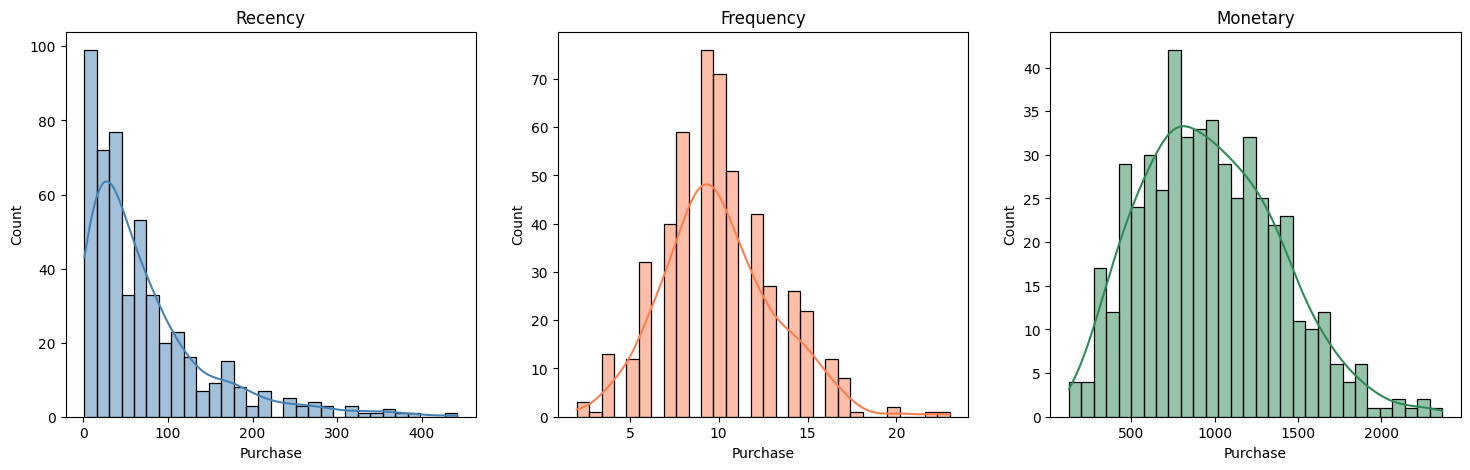

In [39]:
## rfm의 수치에 대한 주기는 월별 기준에 따라 달라진다.
import seaborn as sns

plt.figure(figsize = (18, 5))

##Recency
plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins = 30, kde = True, color = 'steelblue')
plt.title('Recency')
plt.xlabel('Purchase')

## Frequncy
plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins = 30, kde=True, color='coral')
plt.title('Frequency')
plt.xlabel('Purchase')

##Monetary
plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins = 30, kde = True, color = 'seagreen')
plt.title('Monetary')
plt.xlabel('Purchase')

In [41]:
## 통계적인 분포 모형 불러오기

from scipy.stats import expon, poisson, gamma

## 평균의 기반으로 파라미터 추정
lambda_r = 1/rfm['Recency'].mean()
mu_f = rfm['Frequency'].mean()
a_m, loc_m, scale_m = gamma.fit(rfm['Monetary'], floc = 0)

# 확률을 계산해보자
rfm['recency_prob'] = expon.cdf(rfm['Recency'], scale = 1/lambda_r)
rfm['frequency_prob'] = poisson.pmf(rfm['Frequency'], mu=mu_f)
rfm['monetary_prob'] = gamma.cdf(rfm['Monetary'], a=a_m, loc = loc_m, scale = scale_m)

In [43]:
rfm

,customer_id,Recency,Frequency,Monetary,recency_prob,frequency_prob,monetary_prob
0,C0001,163,10,1153.44,0.897498,0.125110,0.705377
1,C0002,19,10,1175.34,0.233192,0.125110,0.720591
2,C0003,49,7,458.09,0.495788,0.090079,0.088796
3,C0004,72,15,1336.49,0.634386,0.034718,0.815315
4,C0005,45,17,1778.77,0.466801,0.012764,0.950260
...,...,...,...,...,...,...,...
495,C0496,30,11,1062.86,0.342454,0.113736,0.636451
496,C0497,69,12,763.50,0.618732,0.094780,0.354819
497,C0498,166,8,1189.65,0.901706,0.112599,0.730225
498,C0499,109,10,881.96,0.781996,0.125110,0.473115


In [44]:
a_m

5.050496944898523

In [46]:
mu_f

np.float64(10.0)

In [47]:
scale_m

np.float64(192.68543088279267)

In [48]:
df_orders

,customer_id,order_date,amount,category,device,discount_used,channel,year_month,year_week,weekday
0,C0328,2022-04-13,159.23,Electronics,Mobile,0,Website,2022-04,2022-15,2
1,C0378,2022-09-28,131.67,Electronics,Desktop,1,Website,2022-09,2022-39,2
2,C0217,2023-12-02,90.84,Electronics,Mobile,0,App,2023-12,2023-48,5
3,C0014,2022-05-02,16.96,Books,Mobile,0,App,2022-05,2022-18,0
4,C0113,2022-11-27,61.48,Grocery,Mobile,1,Website,2022-11,2022-48,6
...,...,...,...,...,...,...,...,...,...,...
4995,C0313,2023-02-28,283.25,Grocery,Desktop,0,Website,2023-02,2023-09,1
4996,C0387,2023-01-17,20.56,Beauty,Mobile,0,App,2023-01,2023-03,1
4997,C0457,2023-11-05,516.52,Sports,Mobile,0,Website,2023-11,2023-45,6
4998,C0392,2022-10-04,15.00,Grocery,Mobile,1,App,2022-10,2022-40,1


In [49]:
snapshot_date

Timestamp('2023-12-31 00:00:00')